# Recalculate skills centrality/coreness based on ESCO v.1.0
Felix Zaussinger | 01.09.2022

**Core Analysis Goal(s)**
1. Use Kanders 2021 code to re-calculate skills centrality/coreness for the latest ESCO release (v1.0)
2. Compare GBN categories at skill and occ level
3.

**Key Insight(s)**
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("poster")
#sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

Code ...

In [47]:
import igraph as ig
from src.data.framework import Esco
import scipy
import pingouin as pg
from mapping_career_causeways import cluster_utils
esco = Esco()

#### Read occupation-skills matrix and calculate skills-skills matrix
- [igraph docs](https://igraph.org/python/tutorial/latest/tutorial.html#treating-a-graph-as-an-adjacency-matrix)
- In adjacency matrix, rows and columns are labeled by graph vertices: the elements of the matrix indicate whether the vertices i and j have a common edge (i, j). The adjacency matrix for the example graph is

In [16]:
%%time
# read bipartite adjecency matrix for occupations and skills
osm = pd.read_pickle(os.path.join(useful_paths.data_interim, "esco", "occ_skills_matrix.pkl"))
osm_sparse = scipy.sparse.csr_matrix(osm.values)

# Co-occurrence matrix
W_sparse = osm_sparse.T.dot(osm_sparse)
W = W_sparse.toarray()
np.fill_diagonal(W,0)

# Adjacency matrix of the co-occurrence graph
A = np.zeros(W.shape)
A[W!=0] = 1

CPU times: total: 2.52 s
Wall time: 2.79 s


Build graph

In [20]:
graph = cluster_utils.build_graph(W, A)

Building the graph... done!


#### Calculate 'coreness' (might take a few minutes)

- **Eigenvector centrality**
    - how important is a node (skill) together with the importance (weight?) of its neighbours (and their neighbours...)?
    - can identify nodes with influence over the whole network, not just those directly connected to it.

- **Betweenness centrality**
    - how often does a node (skill) lie on the shortest paths between two other nodes (skills)?
    - This measure shows which nodes are ‘bridges’ between nodes in a network.

![Centrality comparison 1](../../references/Example-of-eigenvector-centrality.png)
[Ref](https://www.researchgate.net/figure/Example-of-eigenvector-centrality_fig1_311975848)

![Centrality comparison 2](../../references/Pictorial-description-of-In-degree-Eigenvector-centrality-and-betweenness-centrality.png)
[Ref](https://www.researchgate.net/figure/Pictorial-description-of-In-degree-Eigenvector-centrality-and-betweenness-centrality_fig1_313416055)

- **Clustering coefficient**
    - how well are the neighbours of a node (skills) connected?
    - degree to which nodes in a graph tend to cluster together
    - abundance of connected triangles in a network
    - extent to which edges of a network cluster in terms of triangles

![Clustering coefficient](../../references/An-example-of-clustering-coefficient-Three-network-configurations-that-result-in.png)
[Ref](https://www.researchgate.net/figure/An-example-of-clustering-coefficient-Three-network-configurations-that-result-in_fig2_324745118)

In [22]:
# Eigenvector centrality, e
centrality_unweighted = graph.evcent(directed=False, scale=True, weights=None)

# Betweenness centrality, b
betweenness = graph.betweenness(directed=False)

# Clustering coefficient, c
clustering_coeff = graph.transitivity_local_undirected()

# Normalise betweenness centrality between 0 and 1, b_norm
betweenness_norm = np.array(betweenness) / np.max(betweenness)

# Average b_norm and e
mean_centrality = 0.5*np.array(betweenness_norm) + 0.5*np.array(centrality_unweighted)

# Multiply averaged centarlity with (1-c) to select skills that are high on both measures
m = mean_centrality*(1-np.array(clustering_coeff))

# Deal with nulls
m[np.where(np.isnan(m))[0]] = 0

# Normalise between 0 and 1
m = m / np.max(m)

#### Maximum spanning tree (Hidalgo 2007)
- I have a graph and want to obtain the maximum spanning tree, therefore I obtain the minimum spanning tree of the graph with inverse weights. ([REF](https://stackoverflow.com/questions/46103615/igraph-maximum-spanning-tree-is-disconnected))

In [63]:
graph.is_directed()

False

In [69]:
graph.is_connected(mode="weak")

False

In [65]:
inv_weight = [1./w for w in graph.es["weight"]]

In [70]:
MST = graph.spanning_tree(weights=inv_weight)

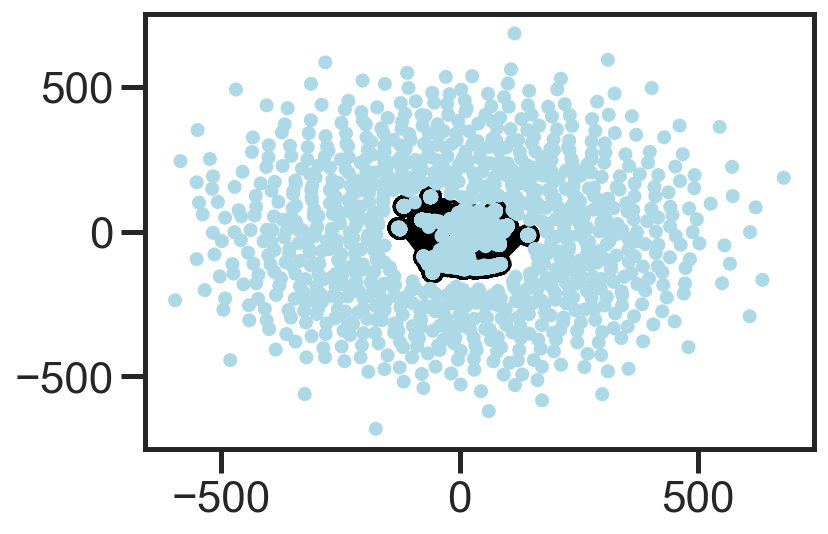

In [71]:
fig, ax = plt.subplots()
ig.plot(
    graph,
    target=ax,
    vertex_color="lightblue",
)

#### Combine network metrics in DF and save

In [39]:
network_metrics = pd.DataFrame(
    columns=osm.columns.values,
    data=[centrality_unweighted, betweenness, betweenness_norm, mean_centrality, clustering_coeff, m],
    index=["eigenvector_centrality", "betweenness_centrality", "betweenness_centrality_norm", "mean_centrality", "clustering_coefficient", "coreness"]
).T

network_metrics.index.name = "conceptUri"

Merge with ESCO skills metadata

In [52]:
esco_skill_clsf = esco.combine_skills_metadata().loc[:, ("conceptUri", "skill_classification_esco")]

In [54]:
skills_network_metrics = pd.merge(esco.skills, network_metrics.reset_index(), on="conceptUri", how="left")
skills_network_metrics_gbn = pd.merge(skills_network_metrics, esco_skill_clsf, on="conceptUri", how="left")

In [60]:
utils.save_df_to_files(
    df=skills_network_metrics_gbn,
    fname_no_ext="skills_network_metrics",
    output_dir=os.path.join(useful_paths.data_processed, "esco")
)

#### Descriptive stats

In [58]:
skills_network_metrics_gbn.describe()

,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness
count,13891.000000,1.389100e+04,13891.000000,13891.000000,13021.000000,13891.000000
mean,0.065726,7.820385e+03,0.002980,0.034353,0.693411,0.021247
std,0.101109,6.088728e+04,0.023198,0.056899,0.253144,0.051396
min,0.000000,0.000000e+00,0.000000,0.000000,0.060475,0.000000
25%,0.010394,0.000000e+00,0.000000,0.005217,0.495557,0.000000
50%,0.024489,1.934840e+02,0.000074,0.012384,0.693452,0.003914
75%,0.074658,1.590170e+03,0.000606,0.038046,0.992902,0.017893
max,1.000000,2.624645e+06,1.000000,0.913037,1.000000,1.000000


In [59]:
skills_network_metrics_gbn.rcorr()

,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness
eigenvector_centrality,-,***,***,***,***,***
betweenness_centrality,0.467,-,***,***,***,***
betweenness_centrality_norm,0.467,1.0,-,***,***,***
mean_centrality,0.984,0.618,0.618,-,***,***
clustering_coefficient,-0.553,-0.261,-0.261,-0.544,-,***
coreness,0.908,0.736,0.736,0.957,-0.567,-
